1. Reading emails.csv and parsing network...
Network built! Nodes: 15604, Edges: 53232

2. Calculating Centrality Metrics...
Top 10 by In-Degree:
[('sally.beck@enron.com', 539), ('don.baughman@enron.com', 356), ('rick.buy@enron.com', 297), ('michelle.cash@enron.com', 259), ('lcampbel@enron.com', 187), ('john.arnold@enron.com', 163), ('lynn.blair@enron.com', 151), ('harry.arora@enron.com', 142), ('larry.campbell@enron.com', 141), ('eric.bass@enron.com', 139)]

Top 10 by Out-Degree:
[('sally.beck@enron.com', 1245), ('kenneth.lay@enron.com', 915), ('david.forster@enron.com', 821), ('bob.ambrocik@enron.com', 795), ('daniel.muschar@enron.com', 721), ('julie.clyatt@enron.com', 713), ('technology.enron@enron.com', 708), ('david.oxley@enron.com', 612), ('neil.davies@enron.com', 510), ('tom.wilbeck@enron.com', 504)]

Computing Betweenness Centrality (this takes a moment)...
Top 10 by Betweenness Centrality:
[('sally.beck@enron.com', 11012951.981512358), ('don.baughman@enron.com', 4297651.547195

/tmp/ipykernel_388/2821051018.py:89: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:102
  eigenvector = enron_ig.eigenvector_centrality(directed=True)


Louvain algorithm found 253 distinct communities.
Community sizes: [253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 253, 25

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


5. Plotting Degree Distribution...


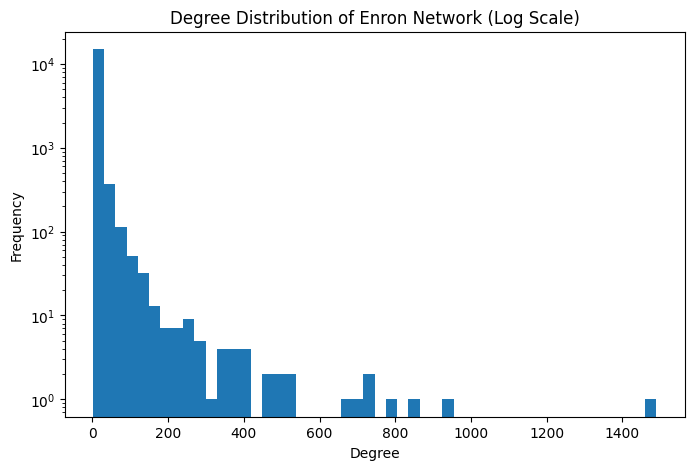

Saved degree distribution plot as 'degree_distribution.png'.

6. Calculating Global Metrics (on Largest Connected Component)...
Diameter of LCC: 9
Average Shortest Path of LCC: 4.04

7. Zipping files for download...
Triggering download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install igraph python-louvain

import pandas as pd
import email
import networkx as nx
import igraph as ig
import json
import os
import zipfile
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain # Louvain algorithm
from google.colab import files
from collections import defaultdict

# ==========================================
# 1. DATA PARSING & NETWORK CONSTRUCTION
# ==========================================
print("1. Reading emails.csv and parsing network...")
# LIMITING to 50,000 rows to prevent Colab from crashing.
# Remove `nrows=50000` ONLY if you have sufficient RAM.
df = pd.read_csv('emails.csv', usecols=['message'], nrows=50000)

edges = []

for msg_text in df['message']:
    msg = email.message_from_string(msg_text)
    sender = msg['From']
    receiver = msg['To']

    if sender and receiver:
        receivers = str(receiver).replace('\n', '').replace('\t', '').split(',')
        for rec in receivers:
            # We strip extra spaces from the ends of the strings
            edges.append((sender.strip(), rec.strip()))

# Load directly into NetworkX from the Python list
enron_graph = nx.DiGraph()
enron_graph.add_edges_from(edges)

# Save safely to a file for your final zip download using a TAB delimiter
enron_file_path = "enron_network.edgelist"
nx.write_edgelist(enron_graph, enron_file_path, delimiter='\t', data=False)

print(f"Network built! Nodes: {enron_graph.order()}, Edges: {enron_graph.size()}\n")


# ==========================================
# 2. CENTRALITY METRICS & JSON EXPORT
# ==========================================
print("2. Calculating Centrality Metrics...")

# Degree Centrality
in_degree_list = list(enron_graph.in_degree())
out_degree_list = list(enron_graph.out_degree())

in_degree_list.sort(key=lambda x: x[1], reverse=True)
out_degree_list.sort(key=lambda x: x[1], reverse=True)

print(f"Top 10 by In-Degree:\n{in_degree_list[:10]}\n")
print(f"Top 10 by Out-Degree:\n{out_degree_list[:10]}\n")

# Convert to igraph for faster complex computations
enron_ig = ig.Graph.from_networkx(enron_graph)

# Betweenness Centrality
betweenness_json_file = "enron_betweenness_centrality.json"
if os.path.exists(betweenness_json_file):
    print("Loading Betweenness Centrality from JSON...")
    with open(betweenness_json_file, "r") as f:
        betweenness_list = json.load(f)
else:
    print("Computing Betweenness Centrality (this takes a moment)...")
    betweenness = enron_ig.betweenness(directed=True)
    betweenness_list = list(zip(enron_ig.vs['_nx_name'], betweenness))
    with open(betweenness_json_file, "w") as f:
        json.dump(betweenness_list, f)

betweenness_list.sort(key=lambda x: x[1], reverse=True)
print(f"Top 10 by Betweenness Centrality:\n{betweenness_list[:10]}\n")

# Eigenvector Centrality
eigenvector_json_file = "enron_eigenvector_centrality.json"
if os.path.exists(eigenvector_json_file):
    print("Loading Eigenvector Centrality from JSON...")
    with open(eigenvector_json_file, "r") as f:
        eigenvector_list = json.load(f)
else:
    print("Computing Eigenvector Centrality...")
    eigenvector = enron_ig.eigenvector_centrality(directed=True)
    eigenvector_list = list(zip(enron_ig.vs['_nx_name'], eigenvector))
    with open(eigenvector_json_file, "w") as f:
        json.dump(eigenvector_list, f)

eigenvector_list.sort(key=lambda x: x[1], reverse=True)
print(f"Top 10 by Eigenvector Centrality:\n{eigenvector_list[:10]}\n")


# ==========================================
# 3. TOP 10% INTERSECTIONS
# ==========================================
print("3. Calculating Top 10% Overlaps...")
top_10_percent = int(0.1 * len(in_degree_list))

in_set = set(map(lambda x: x[0], in_degree_list[:top_10_percent]))
out_set = set(map(lambda x: x[0], out_degree_list[:top_10_percent]))
bw_set = set(map(lambda x: x[0], betweenness_list[:top_10_percent]))
ev_set = set(map(lambda x: x[0], eigenvector_list[:top_10_percent]))

print(f"Nodes in top 10% of In-Degree AND Betweenness: {len(in_set.intersection(bw_set))}")
print(f"Nodes in top 10% of In-Degree AND Eigenvector: {len(in_set.intersection(ev_set))}")


# ==========================================
# 4. COMMUNITY DETECTION (LOUVAIN)
# ==========================================
print("\n4. Performing Community Detection...")
# Louvain requires an undirected graph
undirected_graph = enron_graph.to_undirected()
partition = community_louvain.best_partition(undirected_graph)

# Count communities
num_communities = len(set(partition.values()))
print(f"Louvain algorithm found {num_communities} distinct communities.")
community_sizes = [num_communities for community in partition]
print(f"Community sizes: {community_sizes}")

# Save communities for Gephi visualization later
nx.set_node_attributes(enron_graph, partition, 'community_id')
nx.write_gexf(enron_graph, "enron_communities.gexf")
print("Saved network with communities to 'enron_communities.gexf' for Gephi.")
print("\n--- Top 5 Central Nodes per Community (by In-Degree) ---")
print("    (Ordered by Community Size: Largest to Smallest)")

# 1. Get in-degrees for all nodes for fast lookup
in_degree_dict = dict(enron_graph.in_degree())

# 2. Group nodes by their community ID
community_groups = defaultdict(list)
for node, comm_id in partition.items():
    community_groups[comm_id].append((node, in_degree_dict.get(node, 0)))

# 3. Sort the nodes *within* each community by in-degree (descending)
for comm_id in community_groups:
    community_groups[comm_id].sort(key=lambda x: x[1], reverse=True)

# 4. Sort the communities themselves by size (DESCENDING order)
# Adding reverse=True puts the largest communities at the top
sorted_communities = sorted(community_groups.items(), key=lambda item: len(item[1]), reverse=True)

# 5. Extract top 5, print them, and prepare data for JSON
community_export_data = []

for comm_id, members in sorted_communities:
    top_5 = members[:5]

    # Format the top 5 list into dictionaries for a clean JSON structure
    top_5_formatted = [{"node": node, "in_degree": degree} for node, degree in top_5]

    # Build the dictionary for this specific community
    community_data = {
        "community_id": comm_id,
        "size": len(members),
        "top_5_nodes": top_5_formatted
    }
    community_export_data.append(community_data)

    # Print the results to the console so you can see them immediately
    print(f"\nCommunity {comm_id} (Size: {len(members)} nodes):")
    for rank, (node, degree) in enumerate(top_5, 1):
        print(f"  {rank}. {node} (In-Degree: {degree})")

# 6. Export to JSON and download
json_filename = "top_nodes_per_community.json"

with open(json_filename, "w") as f:
    # indent=4 makes the JSON file nicely formatted and easy for humans to read
    json.dump(community_export_data, f, indent=4)

print(f"\nSaved community rankings to '{json_filename}'. Triggering download...")
files.download(json_filename)

# ==========================================
# 5. DEGREE DISTRIBUTION (POWER LAW)
# ==========================================
print("\n5. Plotting Degree Distribution...")
degrees = [deg for node, deg in undirected_graph.degree()]

plt.figure(figsize=(8, 5))
# A log-log plot is best for visualizing a power law distribution
plt.hist(degrees, bins=50, log=True)
plt.title("Degree Distribution of Enron Network (Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.savefig("degree_distribution.png")
plt.show()
print("Saved degree distribution plot as 'degree_distribution.png'.")


# ==========================================
# 6. DIAMETER & AVERAGE SHORTEST PATH
# ==========================================
print("\n6. Calculating Global Metrics (on Largest Connected Component)...")
# Must extract the Largest Weakly Connected Component first,
# otherwise disconnected nodes return an infinite path length.
components = nx.weakly_connected_components(enron_graph)
lcc_nodes = max(components, key=len)
lcc_graph = enron_graph.subgraph(lcc_nodes)

# Using igraph again because NetworkX shortest paths would take hours
lcc_ig = ig.Graph.from_networkx(lcc_graph)

diameter = lcc_ig.diameter()
avg_path = lcc_ig.average_path_length()

print(f"Diameter of LCC: {diameter}")
print(f"Average Shortest Path of LCC: {avg_path:.2f}")


# ==========================================
# 7. ZIP AND DOWNLOAD RESULTS
# ==========================================
print("\n7. Zipping files for download...")
zip_filename = "enron_full_analysis.zip"

# Added the JSON files to the zip export list
files_to_zip = [
    "enron_network.edgelist",
    "enron_communities.gexf",
    "degree_distribution.png",
    "enron_betweenness_centrality.json",
    "enron_eigenvector_centrality.json"
]

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)

print("Triggering download...")
files.download(zip_filename)

--- ANALYZING VICE PRESIDENT IN-DEGREES ---


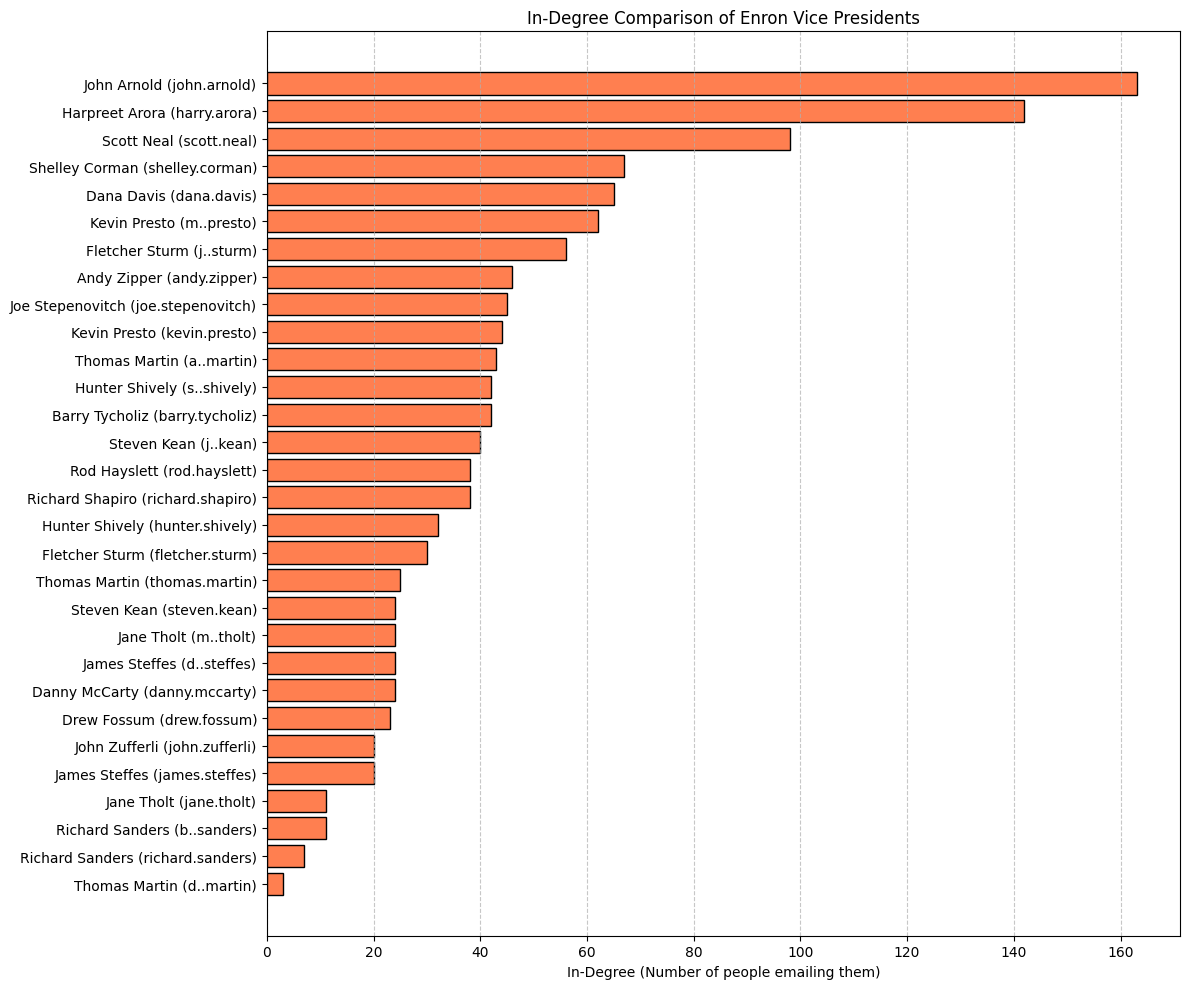

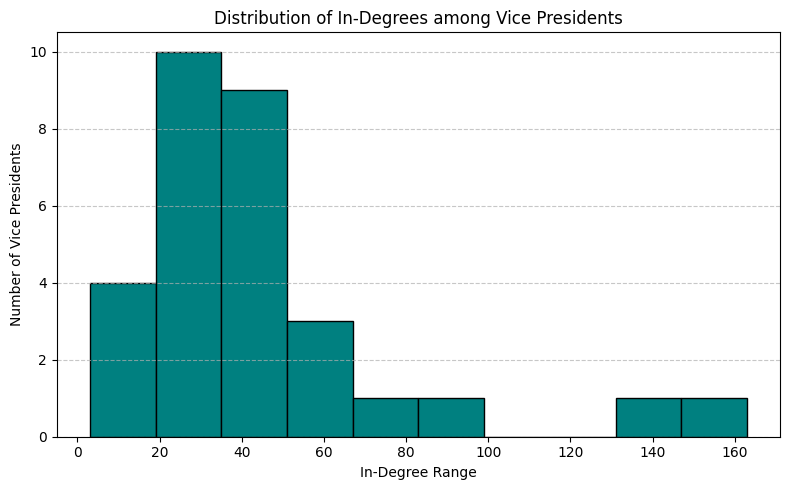


Saved 'vp_indegree_comparison.png' and 'vp_indegree_histogram.png' to Colab files!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("--- ANALYZING VICE PRESIDENT IN-DEGREES ---")

# 1. Define the VP dictionary from your list
# We append '@enron.com' assuming your earlier network nodes use full emails.
# If your nodes don't use '@enron.com', you can remove that part!
vp_data = {
    'a..martin@enron.com': 'Thomas Martin',
    'andy.zipper@enron.com': 'Andy Zipper',
    'barry.tycholiz@enron.com': 'Barry Tycholiz',
    'b..sanders@enron.com': 'Richard Sanders',
    'dana.davis@enron.com': 'Dana Davis',
    'danny.mccarty@enron.com': 'Danny McCarty',
    'd..martin@enron.com': 'Thomas Martin',
    'drew.fossum@enron.com': 'Drew Fossum',
    'd..steffes@enron.com': 'James Steffes',
    'fletcher.sturm@enron.com': 'Fletcher Sturm',
    'harry.arora@enron.com': 'Harpreet Arora',
    'hunter.shively@enron.com': 'Hunter Shively',
    'james.steffes@enron.com': 'James Steffes',
    'jane.tholt@enron.com': 'Jane Tholt',
    'j..kean@enron.com': 'Steven Kean',
    'joe.stepenovitch@enron.com': 'Joe Stepenovitch',
    'john.arnold@enron.com': 'John Arnold',
    'john.zufferli@enron.com': 'John Zufferli',
    'j..sturm@enron.com': 'Fletcher Sturm',
    'kevin.presto@enron.com': 'Kevin Presto',
    'm..presto@enron.com': 'Kevin Presto',
    'm..tholt@enron.com': 'Jane Tholt',
    'richard.sanders@enron.com': 'Richard Sanders',
    'richard.shapiro@enron.com': 'Richard Shapiro',
    'rod.hayslett@enron.com': 'Rod Hayslett',
    'scott.neal@enron.com': 'Scott Neal',
    'shelley.corman@enron.com': 'Shelley Corman',
    's..shively@enron.com': 'Hunter Shively',
    'steven.kean@enron.com': 'Steven Kean',
    'thomas.martin@enron.com': 'Thomas Martin'
}

# 2. Extract In-Degrees from the graph
vp_indegrees = {}
for email, name in vp_data.items():
    # We check if the node exists in our 50k subset to avoid errors
    if enron_graph.has_node(email):
        degree = enron_graph.in_degree(email)
    else:
        degree = 0 # 0 if they don't appear in this subset of the data

    # Combine name and alias for the chart label
    label = f"{name} ({email.split('@')[0]})"
    vp_indegrees[label] = degree

# Sort by degree for a clean chart
sorted_vps = sorted(vp_indegrees.items(), key=lambda x: x[1], reverse=False)
names = [x[0] for x in sorted_vps]
degrees = [x[1] for x in sorted_vps]

# ==========================================
# PLOT 1: Comparative Bar Chart
# ==========================================
plt.figure(figsize=(12, 10))
plt.barh(names, degrees, color='coral', edgecolor='black')
plt.xlabel("In-Degree (Number of people emailing them)")
plt.title("In-Degree Comparison of Enron Vice Presidents")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("vp_indegree_comparison.png")
plt.show()

# ==========================================
# PLOT 2: True "Distribution" (Histogram)
# ==========================================
# Just in case your guide literally meant a distribution curve/histogram
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=10, color='teal', edgecolor='black')
plt.xlabel("In-Degree Range")
plt.ylabel("Number of Vice Presidents")
plt.title("Distribution of In-Degrees among Vice Presidents")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("vp_indegree_histogram.png")
plt.show()

print("\nSaved 'vp_indegree_comparison.png' and 'vp_indegree_histogram.png' to Colab files!")

In [ ]:
import networkx as nx
from collections import Counter
from google.colab import files

print("--- GENERATING TOP 10 SENDER NETWORKS FOR VPs & SALLY BECK ---")

# 1. Define our targets (Sally + The VPs)
# We removed the duplicate inbox aliases from your previous list to keep the graph clean!
target_people = {
    'sally.beck@enron.com': 'Sally Beck (COO)',
    'a..martin@enron.com': 'Thomas Martin (VP)',
    'andy.zipper@enron.com': 'Andy Zipper (VP)',
    'barry.tycholiz@enron.com': 'Barry Tycholiz (VP)',
    'b..sanders@enron.com': 'Richard Sanders (VP)',
    'dana.davis@enron.com': 'Dana Davis (VP)',
    'danny.mccarty@enron.com': 'Danny McCarty (VP)',
    'drew.fossum@enron.com': 'Drew Fossum (VP)',
    'd..steffes@enron.com': 'James Steffes (VP)',
    'fletcher.sturm@enron.com': 'Fletcher Sturm (VP)',
    'harry.arora@enron.com': 'Harpreet Arora (VP)',
    'hunter.shively@enron.com': 'Hunter Shively (VP)',
    'jane.tholt@enron.com': 'Jane Tholt (VP)',
    'j..kean@enron.com': 'Steven Kean (VP)',
    'joe.stepenovitch@enron.com': 'Joe Stepenovitch (VP)',
    'john.arnold@enron.com': 'John Arnold (VP)',
    'john.zufferli@enron.com': 'John Zufferli (VP)',
    'kevin.presto@enron.com': 'Kevin Presto (VP)',
    'richard.shapiro@enron.com': 'Richard Shapiro (VP)',
    'rod.hayslett@enron.com': 'Rod Hayslett (VP)',
    'scott.neal@enron.com': 'Scott Neal (VP)',
    'shelley.corman@enron.com': 'Shelley Corman (VP)'
}

# 2. Count the exact number of emails between every pair of people
# 'edges' is the raw list you generated in Section 1 of your code
edge_weights = Counter(edges)

# 3. Create a brand new, empty graph just for this specific visualization
top10_graph = nx.DiGraph()

# 4. Find the Top 10 senders for each target person
for target_email, target_name in target_people.items():
    # Get all edges where the receiver is our target
    incoming = {sender: count for (sender, receiver), count in edge_weights.items() if receiver == target_email}

    # Sort them by the number of emails (descending) and grab the top 10
    top_10_senders = sorted(incoming.items(), key=lambda x: x[1], reverse=True)[:10]

    # Add these specific edges to our new graph
    for sender, count in top_10_senders:
        # We add the target and the sender as nodes
        top10_graph.add_node(target_email, label=target_name, Role="Target Executive")
        top10_graph.add_node(sender, Role="Sender")

        # CRITICAL STEP: We add the email count as a 'weight'.
        # Gephi will use this to make lines thicker if they sent more emails!
        top10_graph.add_edge(sender, target_email, weight=count)

print(f"Successfully isolated {top10_graph.number_of_nodes()} highly connected people.")
print(f"Created {top10_graph.number_of_edges()} edges representing their strongest communication channels.")

# 5. Export directly to Gephi format
gexf_filename = "VP_and_Sally_Top10_Networks.gexf"
nx.write_gexf(top10_graph, gexf_filename)

print(f"\nSaved as '{gexf_filename}'! Triggering download...")
files.download(gexf_filename)

--- ANALYZING TOP 10 SENDERS FOR ENRON EXECUTIVES ---
Graph built with 151 highly connected people.

Rendering Network Graph (This takes a few seconds)...


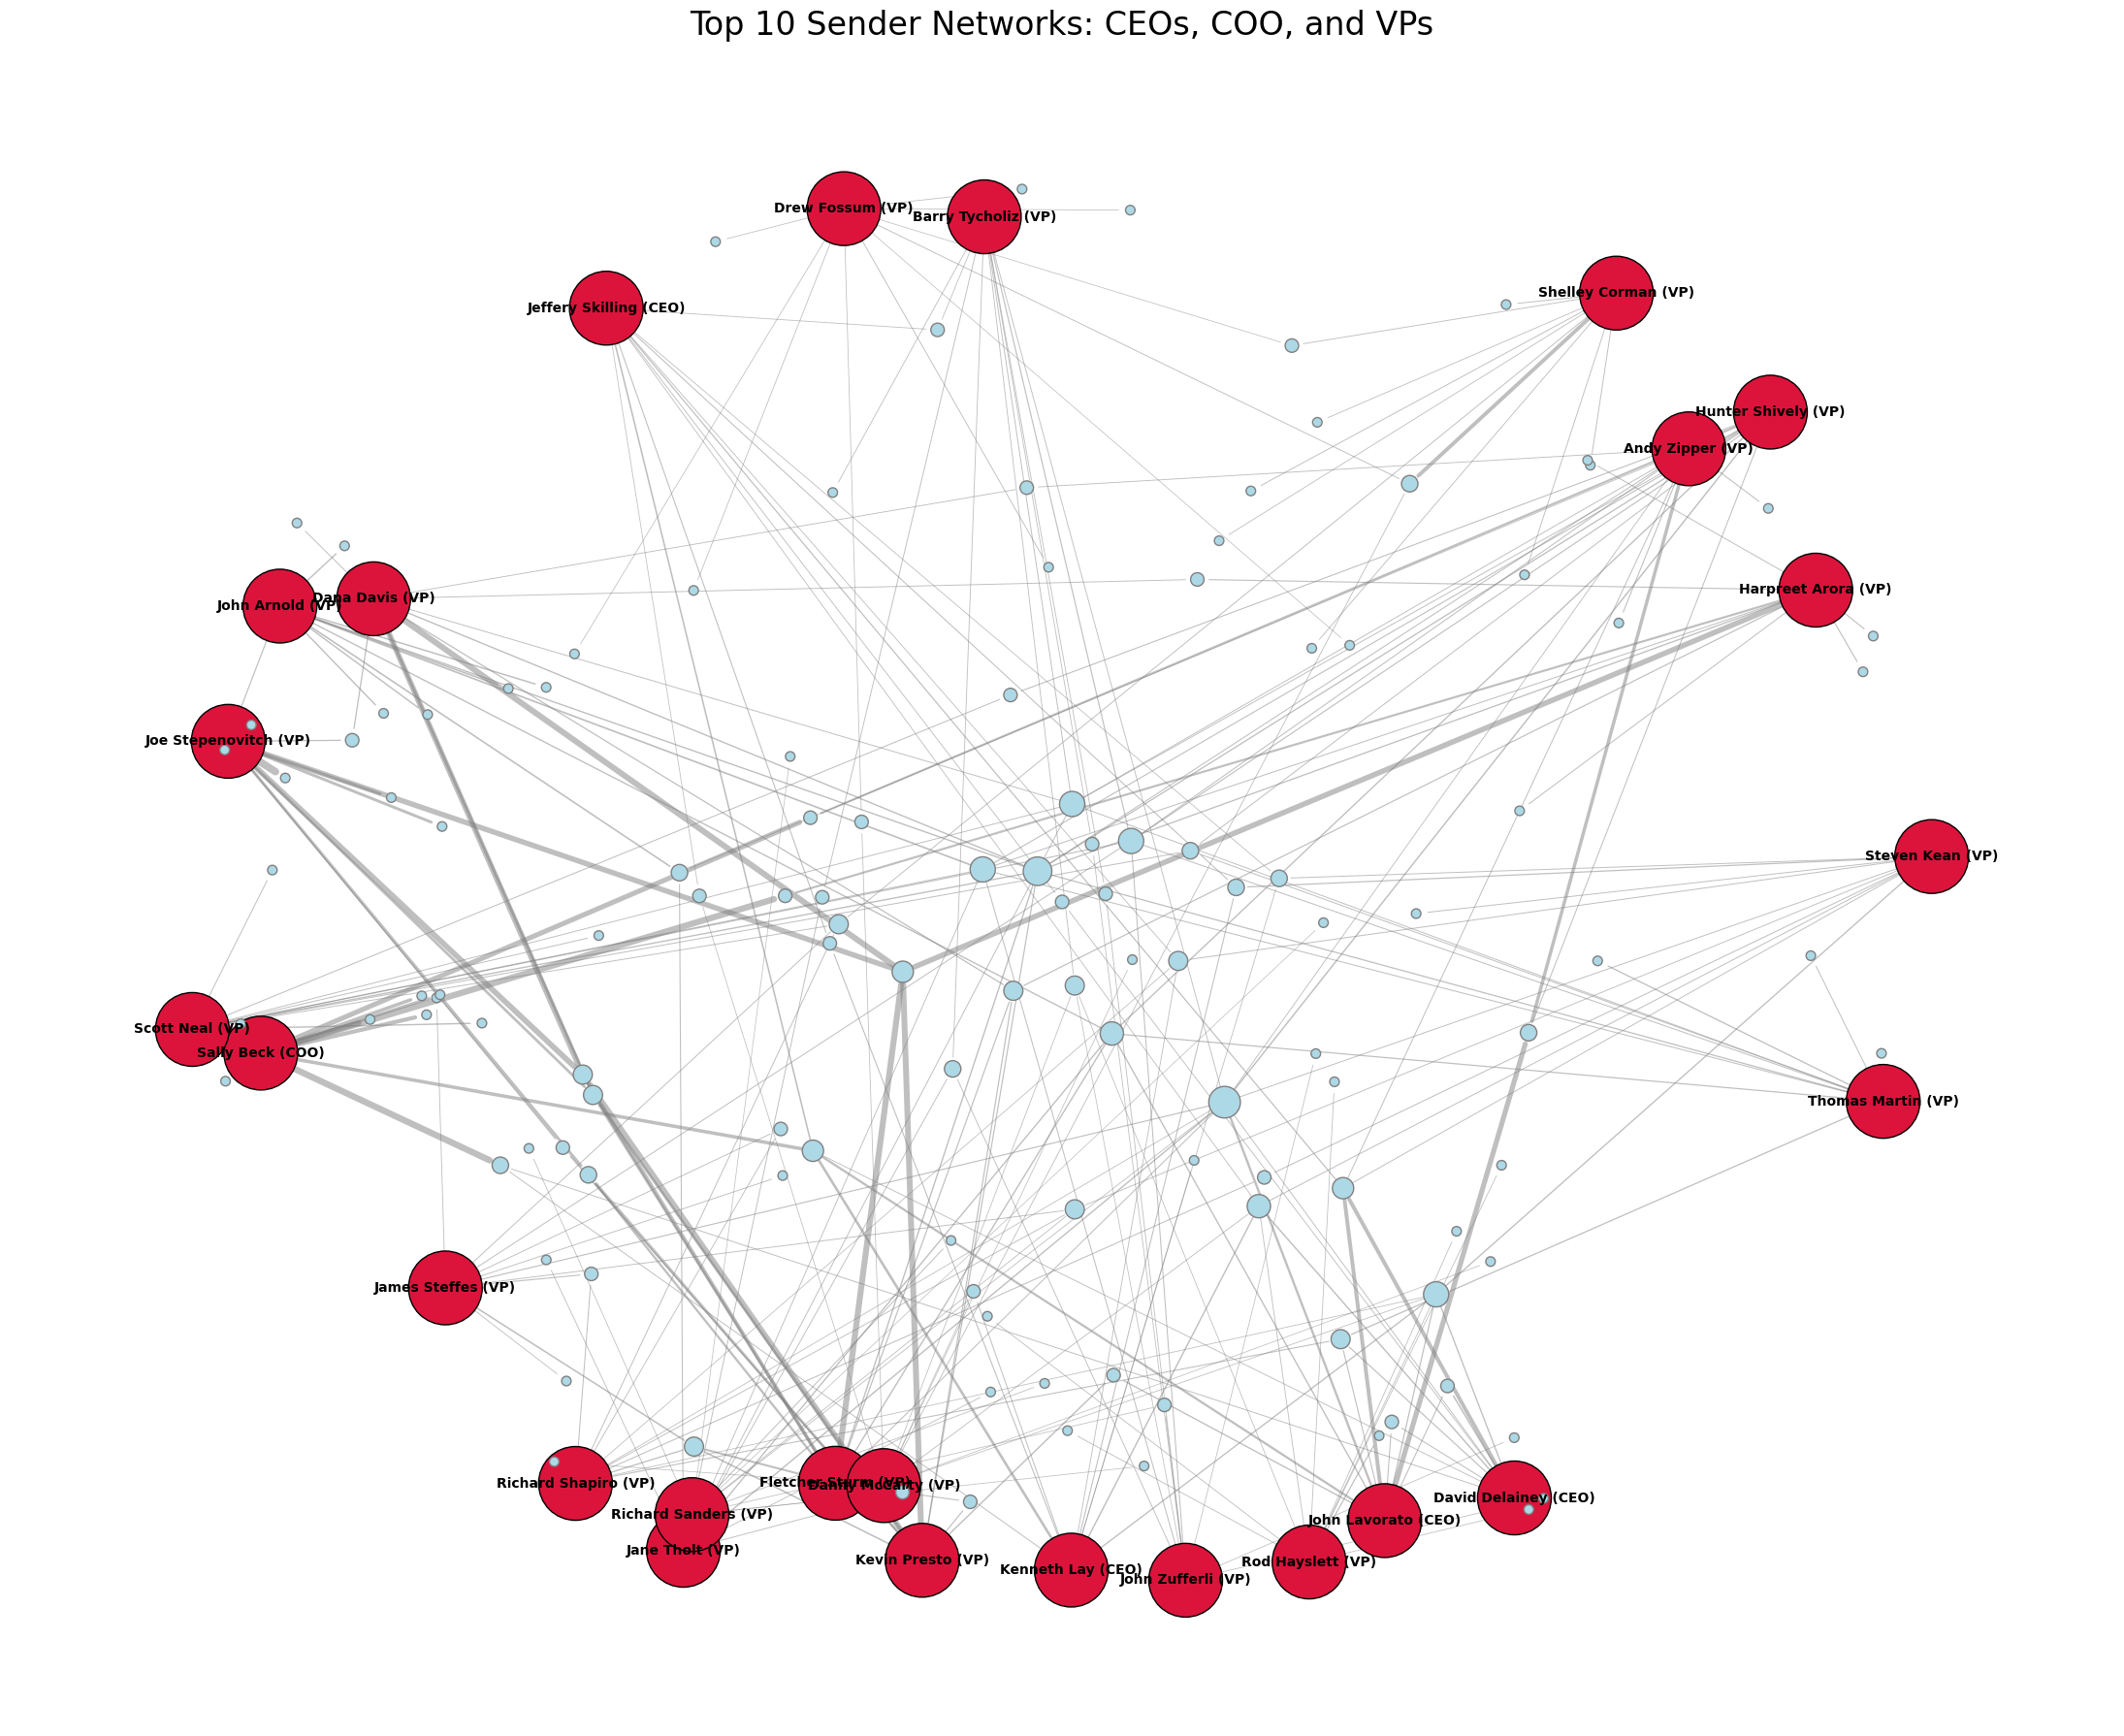


Rendering Bar Chart Grid...


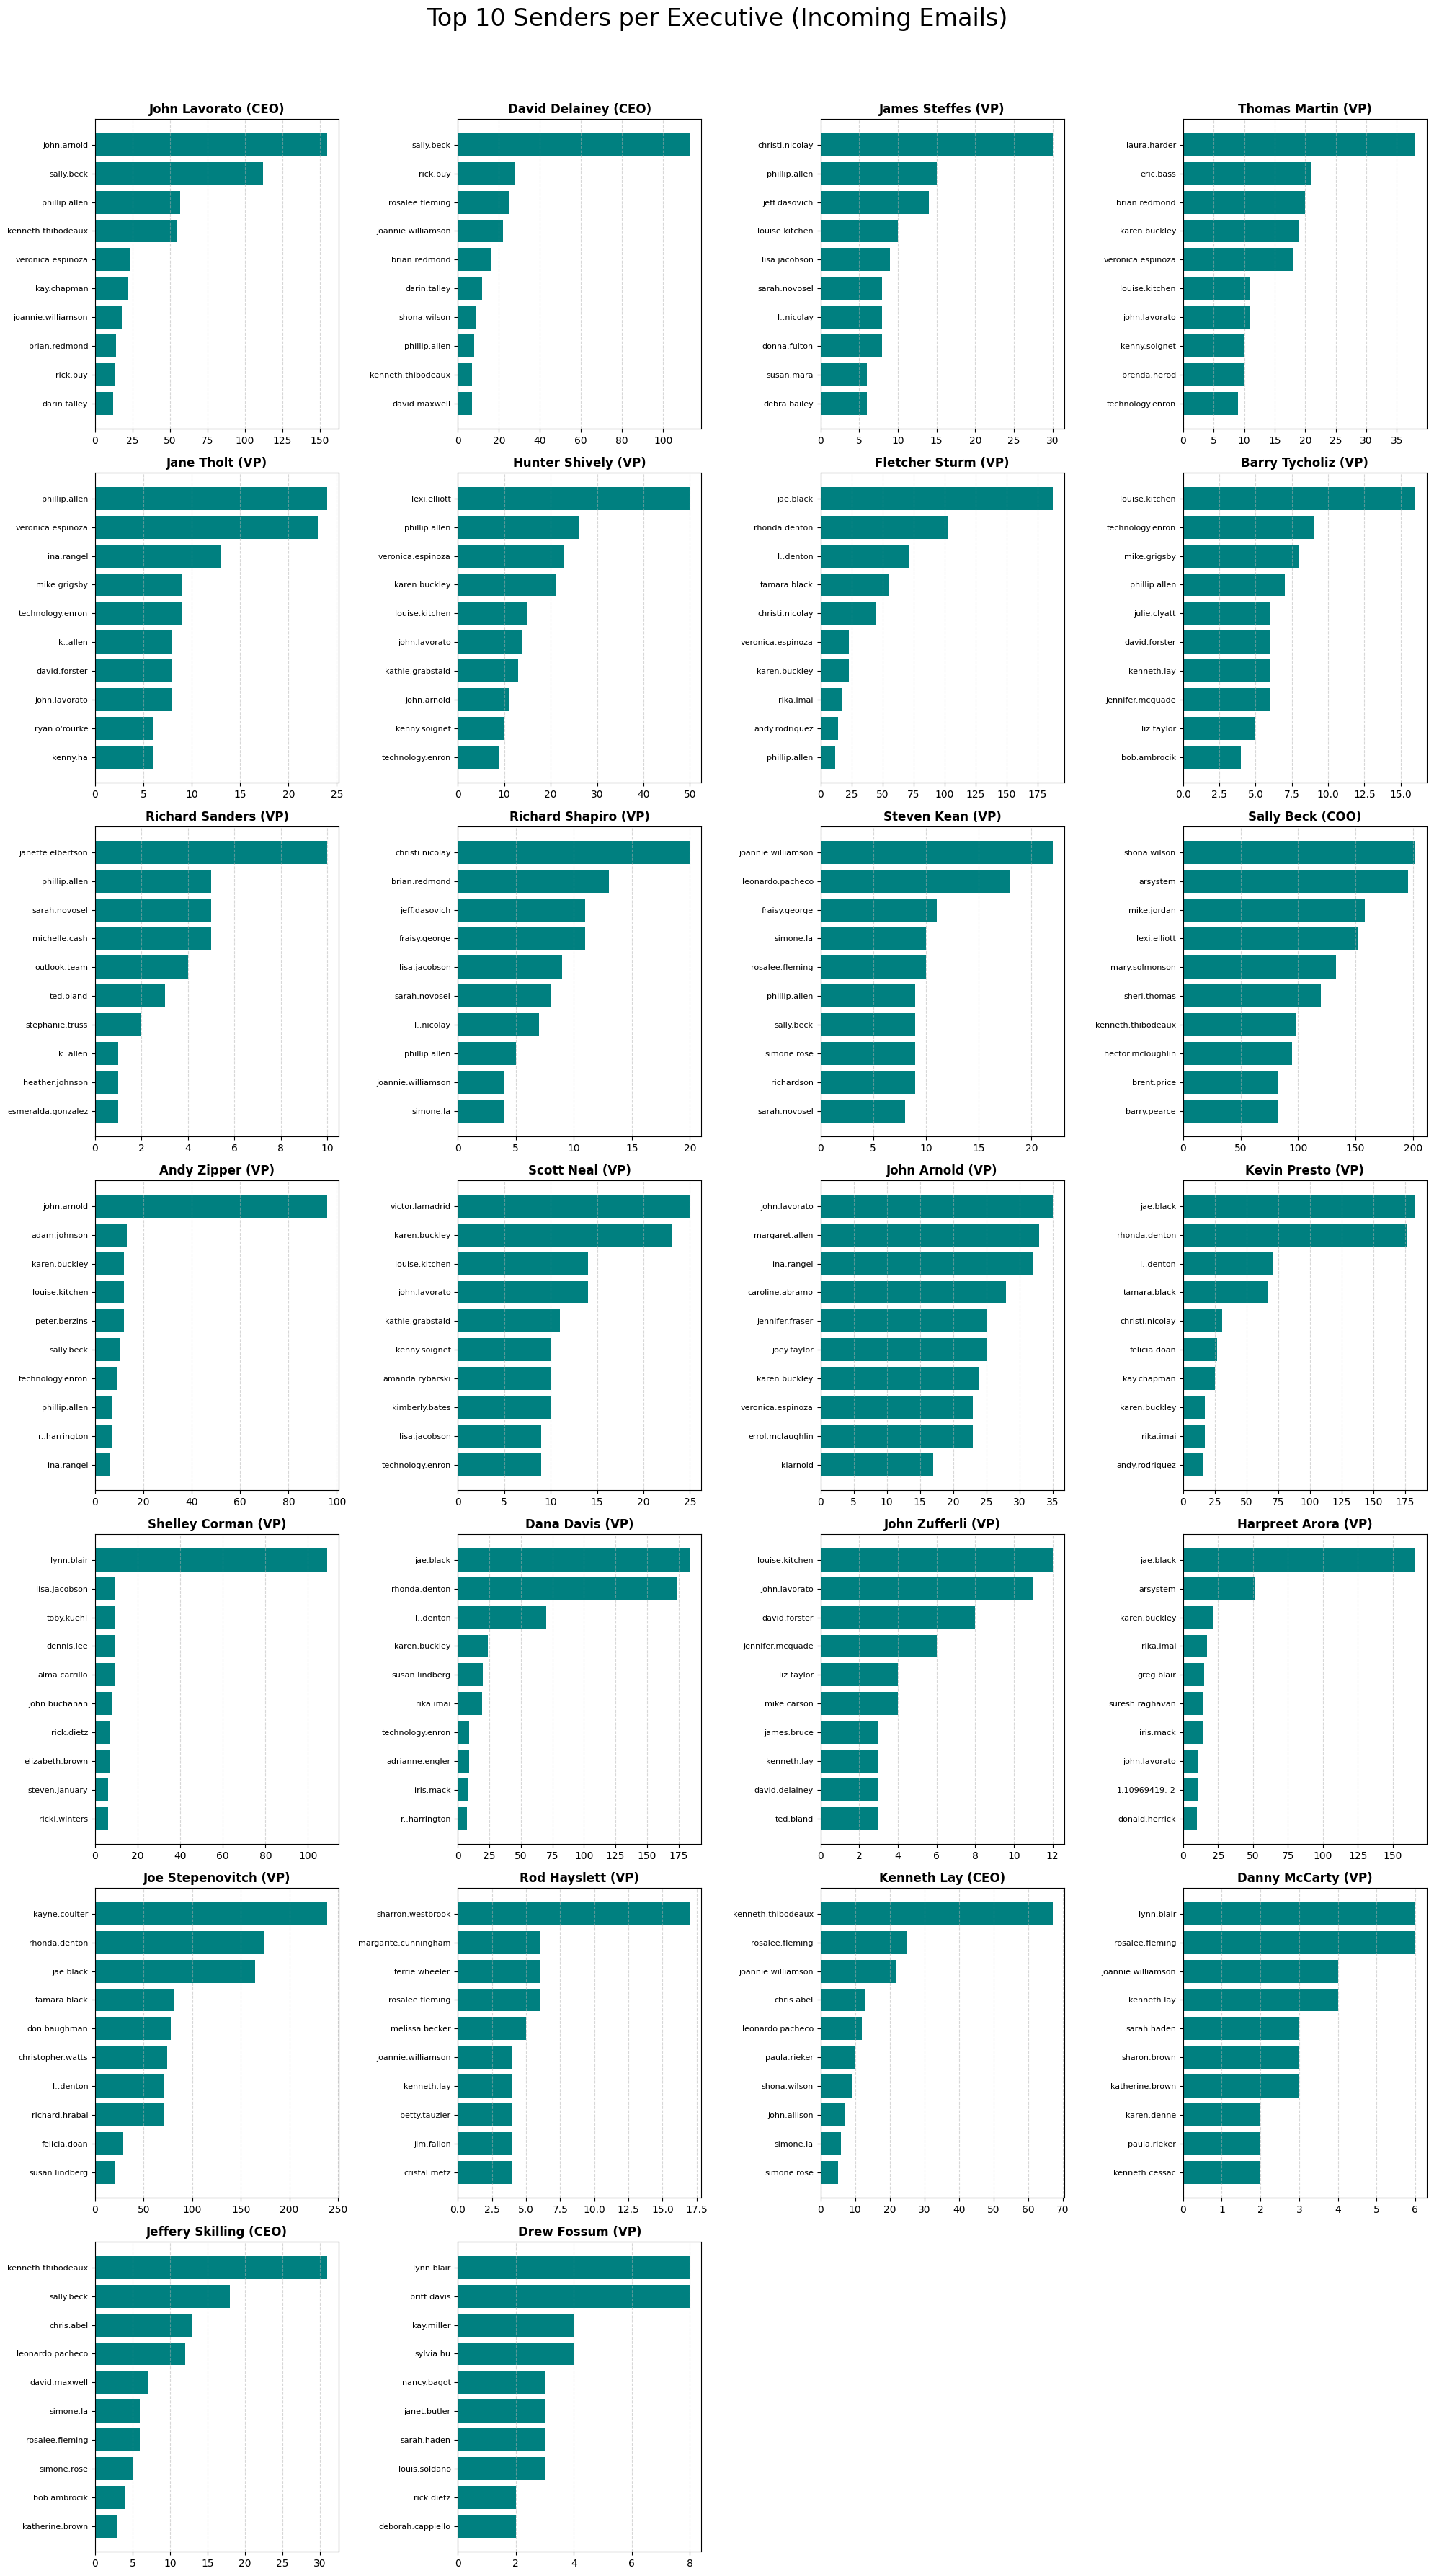


Triggering file downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from google.colab import files
import math

print("--- ANALYZING TOP 10 SENDERS FOR ENRON EXECUTIVES ---")

# 1. Map all raw email aliases to their exact human and role
# This combines duplicate inboxes so the data is 100% accurate!
exec_mapping = {
    'a..martin@enron.com': 'Thomas Martin (VP)',
    'd..martin@enron.com': 'Thomas Martin (VP)',
    'thomas.martin@enron.com': 'Thomas Martin (VP)',
    'andy.zipper@enron.com': 'Andy Zipper (VP)',
    'barry.tycholiz@enron.com': 'Barry Tycholiz (VP)',
    'b..sanders@enron.com': 'Richard Sanders (VP)',
    'richard.sanders@enron.com': 'Richard Sanders (VP)',
    'dana.davis@enron.com': 'Dana Davis (VP)',
    'danny.mccarty@enron.com': 'Danny McCarty (VP)',
    'drew.fossum@enron.com': 'Drew Fossum (VP)',
    'd..steffes@enron.com': 'James Steffes (VP)',
    'james.steffes@enron.com': 'James Steffes (VP)',
    'fletcher.sturm@enron.com': 'Fletcher Sturm (VP)',
    'j..sturm@enron.com': 'Fletcher Sturm (VP)',
    'harry.arora@enron.com': 'Harpreet Arora (VP)',
    'hunter.shively@enron.com': 'Hunter Shively (VP)',
    's..shively@enron.com': 'Hunter Shively (VP)',
    'jane.tholt@enron.com': 'Jane Tholt (VP)',
    'm..tholt@enron.com': 'Jane Tholt (VP)',
    'j..kean@enron.com': 'Steven Kean (VP)',
    'steven.kean@enron.com': 'Steven Kean (VP)',
    'joe.stepenovitch@enron.com': 'Joe Stepenovitch (VP)',
    'john.arnold@enron.com': 'John Arnold (VP)',
    'john.zufferli@enron.com': 'John Zufferli (VP)',
    'kevin.presto@enron.com': 'Kevin Presto (VP)',
    'm..presto@enron.com': 'Kevin Presto (VP)',
    'richard.shapiro@enron.com': 'Richard Shapiro (VP)',
    'rod.hayslett@enron.com': 'Rod Hayslett (VP)',
    'scott.neal@enron.com': 'Scott Neal (VP)',
    'shelley.corman@enron.com': 'Shelley Corman (VP)',
    'sally.beck@enron.com': 'Sally Beck (COO)',
    'david.delainey@enron.com': 'David Delainey (CEO)',
    'w..delainey@enron.com': 'David Delainey (CEO)',
    'jeff.skilling@enron.com': 'Jeffery Skilling (CEO)',
    'john.lavorato@enron.com': 'John Lavorato (CEO)',
    'kenneth.lay@enron.com': 'Kenneth Lay (CEO)'
}

# 2. Count the emails per REAL PERSON (Grouping aliases together)
# We assume 'edges' still exists in memory from your very first block!
incoming_counts = defaultdict(Counter)

for sender, receiver in edges:
    if receiver in exec_mapping:
        real_name = exec_mapping[receiver]
        # Skip emails where they email themselves
        if sender not in exec_mapping or exec_mapping.get(sender) != real_name:
            incoming_counts[real_name][sender] += 1

# 3. Build the NetworkX Graph
top10_graph = nx.DiGraph()
executive_top10_data = {} # Save for bar charts

for exec_name, sender_counts in incoming_counts.items():
    # Get Top 10 senders for this specific executive
    top_10 = sender_counts.most_common(10)
    executive_top10_data[exec_name] = top_10

    top10_graph.add_node(exec_name, Role="Executive")
    for sender, count in top_10:
        top10_graph.add_node(sender, Role="Sender")
        top10_graph.add_edge(sender, exec_name, weight=count)

print(f"Graph built with {top10_graph.number_of_nodes()} highly connected people.")

# ==========================================
# PLOT 1: THE NETWORKX GALAXY GRAPH
# ==========================================
print("\nRendering Network Graph (This takes a few seconds)...")
plt.figure(figsize=(22, 18))
pos = nx.spring_layout(top10_graph, k=0.6, iterations=60)

executives = [n for n, d in top10_graph.nodes(data=True) if d.get('Role') == 'Executive']
senders = [n for n, d in top10_graph.nodes(data=True) if d.get('Role') == 'Sender']

# Scale node sizes based on degree
exec_sizes = [top10_graph.degree(n) * 300 for n in executives]
sender_sizes = [top10_graph.degree(n) * 50 for n in senders]

# Edge thickness based on number of emails (scaled down to look clean)
max_weight = max([d['weight'] for u, v, d in top10_graph.edges(data=True)]) if top10_graph.edges() else 1
edge_widths = [(d['weight'] / max_weight) * 5 + 0.5 for u, v, d in top10_graph.edges(data=True)]

# Draw the graph elements

nx.draw_networkx_nodes(top10_graph, pos, nodelist=executives, node_color='crimson', node_size=exec_sizes, edgecolors='black')
nx.draw_networkx_nodes(top10_graph, pos, nodelist=senders, node_color='lightblue', node_size=sender_sizes, edgecolors='gray')
nx.draw_networkx_edges(top10_graph, pos, width=edge_widths, edge_color='gray', alpha=0.5, arrows=True)

# Add Labels for Executives ONLY
labels = {node: node for node in executives}
nx.draw_networkx_labels(top10_graph, pos, labels=labels, font_size=10, font_weight='bold', font_color='black')

plt.title("Top 10 Sender Networks: CEOs, COO, and VPs", fontsize=24)
plt.axis('off')
plt.tight_layout()
plt.savefig("Executive_Network_Map.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# PLOT 2: THE BAR CHART GRID (In-Degree Distribution)
# ==========================================
print("\nRendering Bar Chart Grid...")
num_execs = len(executive_top10_data)
cols = 4
rows = math.ceil(num_execs / cols)

# Create a massive grid to hold all the bar charts
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

# Plot each executive's data in their own square
for idx, (exec_name, top_10) in enumerate(executive_top10_data.items()):
    ax = axes[idx]

    if not top_10:
        ax.set_title(f"{exec_name}\n(No incoming data)", fontsize=10)
        ax.axis('off')
        continue

    senders = [x[0].split('@')[0] for x in top_10] # Clean up emails for the axis
    counts = [x[1] for x in top_10]

    ax.barh(senders[::-1], counts[::-1], color='teal')
    ax.set_title(exec_name, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# Hide any empty squares at the end of the grid
for i in range(num_execs, len(axes)):
    axes[i].axis('off')

plt.suptitle("Top 10 Senders per Executive (Incoming Emails)", fontsize=24, y=1.02)
plt.tight_layout()
plt.savefig("Executive_Bar_Charts.png", dpi=300, bbox_inches='tight')
plt.show()

# Trigger downloads
print("\nTriggering file downloads...")
files.download("Executive_Network_Map.png")
files.download("Executive_Bar_Charts.png")

--- ANALYZING EXECUTIVE-ONLY SUB-NETWORK ---
Sub-network built! 26 Executives and 75 internal connections.


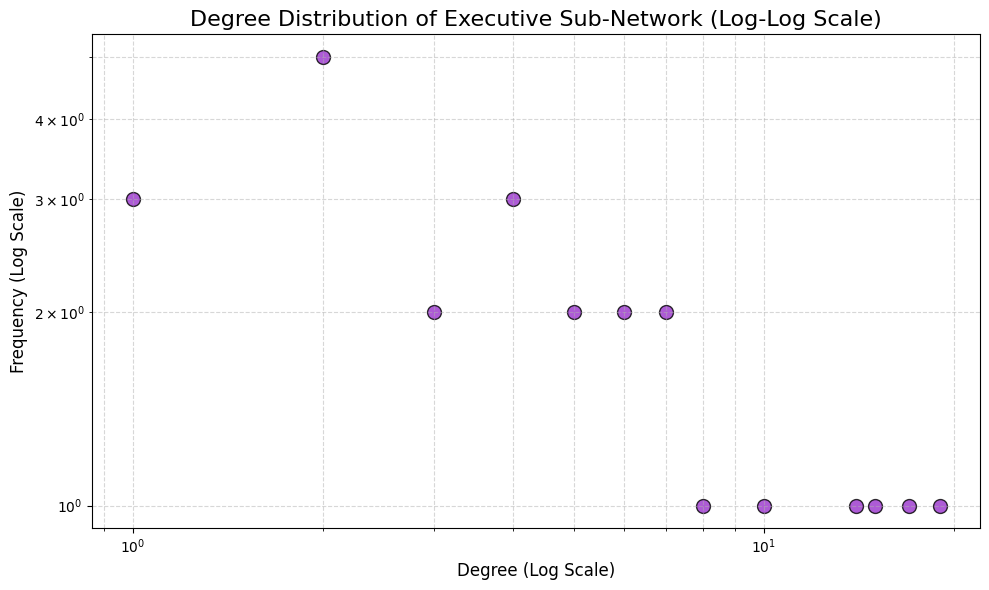


Plot saved! Triggering download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

print("--- ANALYZING EXECUTIVE-ONLY SUB-NETWORK ---")

# 1. Our master list mapping aliases to real people
exec_mapping = {
    'a..martin@enron.com': 'Thomas Martin', 'd..martin@enron.com': 'Thomas Martin', 'thomas.martin@enron.com': 'Thomas Martin',
    'andy.zipper@enron.com': 'Andy Zipper', 'barry.tycholiz@enron.com': 'Barry Tycholiz',
    'b..sanders@enron.com': 'Richard Sanders', 'richard.sanders@enron.com': 'Richard Sanders',
    'dana.davis@enron.com': 'Dana Davis', 'danny.mccarty@enron.com': 'Danny McCarty',
    'drew.fossum@enron.com': 'Drew Fossum', 'd..steffes@enron.com': 'James Steffes', 'james.steffes@enron.com': 'James Steffes',
    'fletcher.sturm@enron.com': 'Fletcher Sturm', 'j..sturm@enron.com': 'Fletcher Sturm',
    'harry.arora@enron.com': 'Harpreet Arora', 'hunter.shively@enron.com': 'Hunter Shively', 's..shively@enron.com': 'Hunter Shively',
    'jane.tholt@enron.com': 'Jane Tholt', 'm..tholt@enron.com': 'Jane Tholt',
    'j..kean@enron.com': 'Steven Kean', 'steven.kean@enron.com': 'Steven Kean',
    'joe.stepenovitch@enron.com': 'Joe Stepenovitch', 'john.arnold@enron.com': 'John Arnold', 'john.zufferli@enron.com': 'John Zufferli',
    'kevin.presto@enron.com': 'Kevin Presto', 'm..presto@enron.com': 'Kevin Presto',
    'richard.shapiro@enron.com': 'Richard Shapiro', 'rod.hayslett@enron.com': 'Rod Hayslett',
    'scott.neal@enron.com': 'Scott Neal', 'shelley.corman@enron.com': 'Shelley Corman',
    'sally.beck@enron.com': 'Sally Beck',
    'david.delainey@enron.com': 'David Delainey', 'w..delainey@enron.com': 'David Delainey',
    'jeff.skilling@enron.com': 'Jeffery Skilling', 'john.lavorato@enron.com': 'John Lavorato', 'kenneth.lay@enron.com': 'Kenneth Lay'
}

# 2. Filter edges: ONLY keep emails where BOTH sender and receiver are executives
# We assume 'edges' is still loaded from your original dataset
executive_edges = []
for sender, receiver in edges:
    if sender in exec_mapping and receiver in exec_mapping:
        real_sender = exec_mapping[sender]
        real_receiver = exec_mapping[receiver]

        # Prevent "self-loops" (executives emailing themselves) from skewing the distribution
        if real_sender != real_receiver:
            executive_edges.append((real_sender, real_receiver))

# 3. Build the closed Executive Graph
exec_graph = nx.Graph() # Using an undirected graph for a standard degree distribution
exec_graph.add_edges_from(executive_edges)

# Ensure all executives are in the graph, even if they sent/received 0 emails to other execs
for person in set(exec_mapping.values()):
    exec_graph.add_node(person)

print(f"Sub-network built! {exec_graph.number_of_nodes()} Executives and {exec_graph.number_of_edges()} internal connections.")

# 4. Calculate Degree Distribution
degrees = [deg for node, deg in exec_graph.degree()]
degree_counts = Counter(degrees)

# Separate into X (Degree) and Y (Frequency) for plotting
x = list(degree_counts.keys())
y = list(degree_counts.values())

# ==========================================
# 5. PLOTTING THE LOG-LOG DISTRIBUTION
# ==========================================
plt.figure(figsize=(10, 6))

# A scatter plot is the standard way to visualize log-log degree distributions
plt.scatter(x, y, color='darkorchid', s=100, alpha=0.8, edgecolor='black')

# Set scales to Logarithmic
plt.xscale('log')
plt.yscale('log')

# Formatting
plt.title("Degree Distribution of Executive Sub-Network (Log-Log Scale)", fontsize=16)
plt.xlabel("Degree (Log Scale)", fontsize=12)
plt.ylabel("Frequency (Log Scale)", fontsize=12)

# Add gridlines to make logarithmic jumps easier to read
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Executive_LogLog_Distribution.png", dpi=300)
plt.show()

print("\nPlot saved! Triggering download...")
from google.colab import files
files.download("Executive_LogLog_Distribution.png")

--- VP/EXECUTIVE DEGREE DISTRIBUTION & PATH LENGTH ---


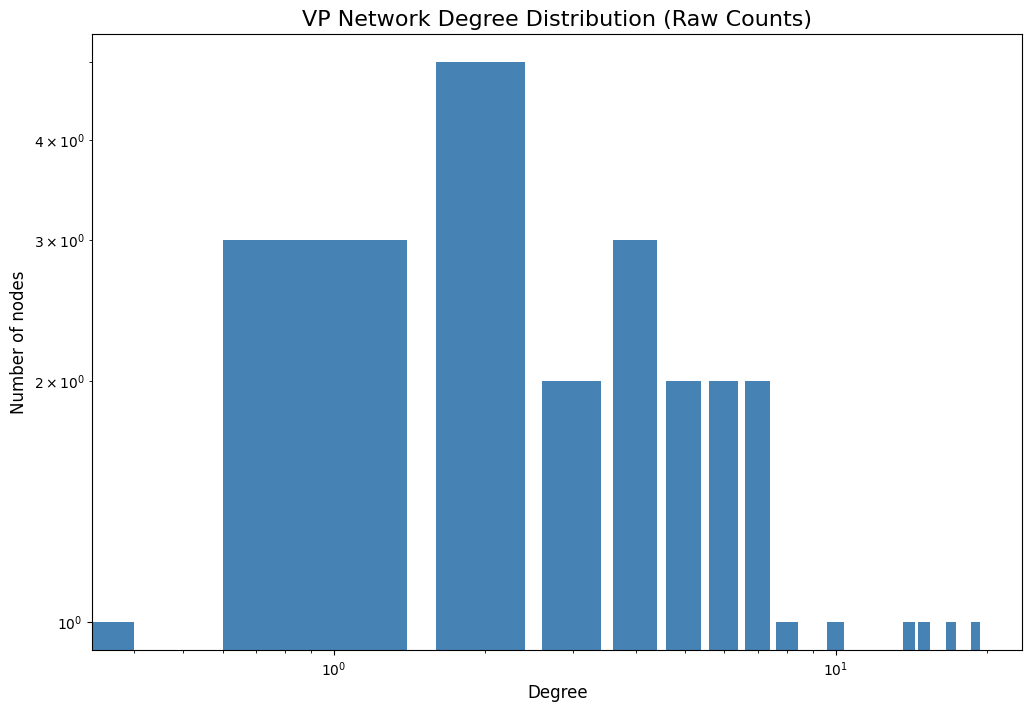

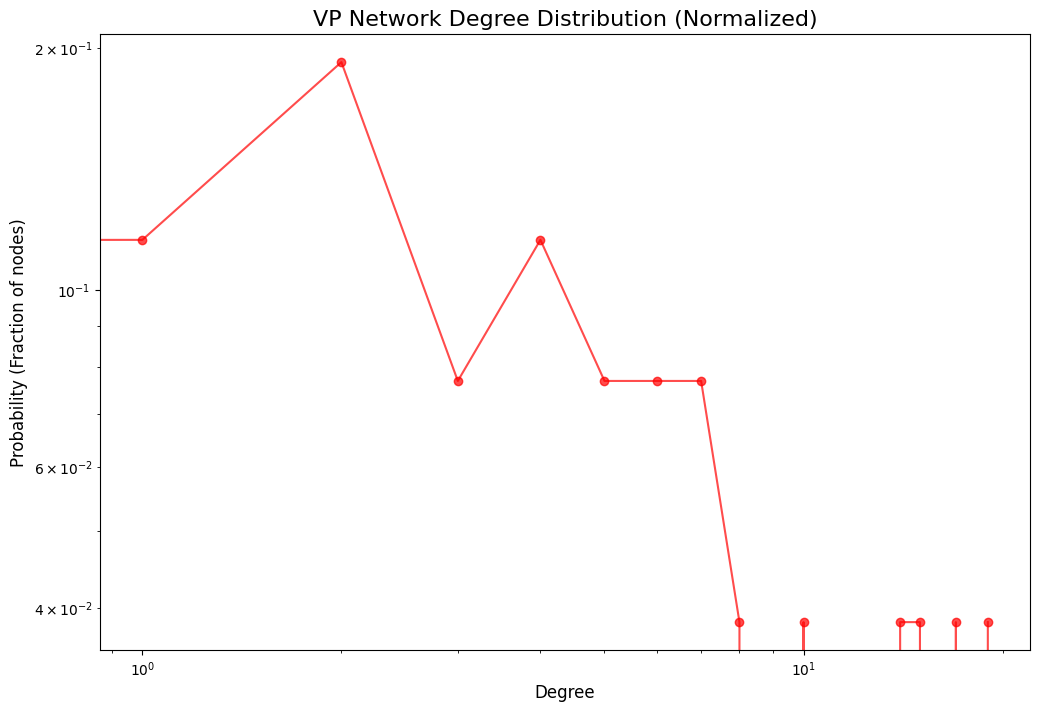


--- NETWORK METRICS ---
Total VPs/Execs in graph: 26
VPs in the main connected group (LCC): 25
Average Shortest Path Length (Main Group): 2.0333
Count of nodes with degree 16: 0


In [6]:
import networkx as nx
import matplotlib.pyplot as plt

print("--- VP/EXECUTIVE DEGREE DISTRIBUTION & PATH LENGTH ---")

# 1. We assume 'executive_edges' and 'exec_mapping' are still in memory from the previous step.
# Let's rebuild the graph so you can run this block cleanly.
exec_graph = nx.Graph()
exec_graph.add_edges_from(executive_edges)

# Ensure all executives are present, even if they have 0 connections
for person in set(exec_mapping.values()):
    exec_graph.add_node(person)

total_execs = exec_graph.number_of_nodes()

# 2. Get the degree histogram (Exact same function from your FB example!)
list_of_degrees = nx.degree_histogram(exec_graph)

# ==========================================
# PLOT 1: Raw Counts (Log-Log Bar Chart)
# ==========================================
plt.figure(figsize=(12, 8))
# Note: matplotlib will naturally ignore bars with a height of 0 on a log scale
plt.bar(range(len(list_of_degrees)), list_of_degrees, color='steelblue')
plt.xlabel("Degree", fontsize=12)
plt.ylabel("Number of nodes", fontsize=12)
plt.yscale("log")
plt.xscale("log")
plt.title("VP Network Degree Distribution (Raw Counts)", fontsize=16)
plt.show()

# ==========================================
# PLOT 2: Normalized Probabilities (Log-Log Line Plot)
# ==========================================
plt.figure(figsize=(12, 8))
# Normalizing by dividing by the total number of VPs (just like you divided by 4039)
normalized_degrees = [x / total_execs for x in list_of_degrees]

# We use 'o-' to show both the point and the line connection
plt.plot(range(len(normalized_degrees)), normalized_degrees, 'ro-', alpha=0.7)
plt.xlabel("Degree", fontsize=12)
plt.ylabel("Probability (Fraction of nodes)", fontsize=12)
plt.yscale("log")
plt.xscale("log")
plt.title("VP Network Degree Distribution (Normalized)", fontsize=16)
plt.show()

# ==========================================
# 3. Average Shortest Path
# ==========================================
print("\n--- NETWORK METRICS ---")


# Check if the graph is fully connected first
if nx.is_connected(exec_graph):
    avg_path = nx.average_shortest_path_length(exec_graph)
    print(f"Average Shortest Path Length (Full Graph): {avg_path:.4f}")
else:
    # If disconnected, we calculate it on the Largest Connected Component
    lcc_nodes = max(nx.connected_components(exec_graph), key=len)
    lcc_subgraph = exec_graph.subgraph(lcc_nodes)
    avg_path = nx.average_shortest_path_length(lcc_subgraph)

    print(f"Total VPs/Execs in graph: {total_execs}")
    print(f"VPs in the main connected group (LCC): {lcc_subgraph.number_of_nodes()}")
    print(f"Average Shortest Path Length (Main Group): {avg_path:.4f}")

# Replicating your final print statement
if len(list_of_degrees) >= 4:
    print(f"Count of nodes with degree {len(list_of_degrees)-4}: {list_of_degrees[-4]}")